In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Check dataset dimensions

print("Dataset Shape:", df.shape)

# View column names

print("\nColumns:")
print(df.columns)

Dataset Shape: (5572, 5)

Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [4]:
# Drop irrelevant columns

df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Rename columns for better readability

df.columns = ['Category', 'Message']

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# Check for missing values

df.isnull().sum()

,0
Category,0
Message,0


In [7]:
# Count spam and ham messages

df['Category'].value_counts()

,count
Category,
ham,4825
spam,747


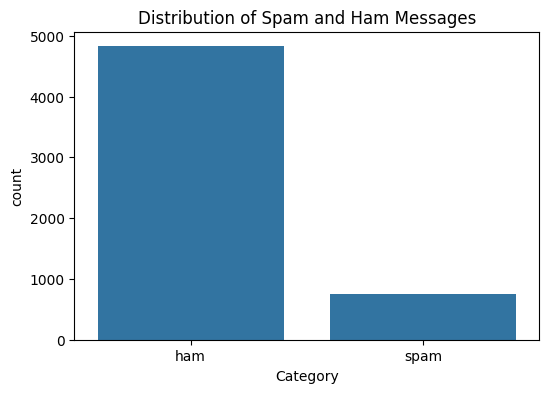

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Category', data=df)

plt.title("Distribution of Spam and Ham Messages")

plt.show()

In [9]:
# Convert text labels into numeric labels

df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Input text

X = df['Message']

# Target label

y = df['Category']

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Transform messages into TF-IDF vectors

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

print(X.shape)

(5572, 8404)


In [12]:
#Train Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4457
Testing Samples: 1115


In [14]:
#Train Model

from sklearn.naive_bayes import MultinomialNB

spam_model = MultinomialNB()

spam_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [15]:
# Generate Predictions

predictions = spam_model.predict(X_test)

predictions[:10]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [16]:
#Evaluate Model

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.968609865470852


In [17]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



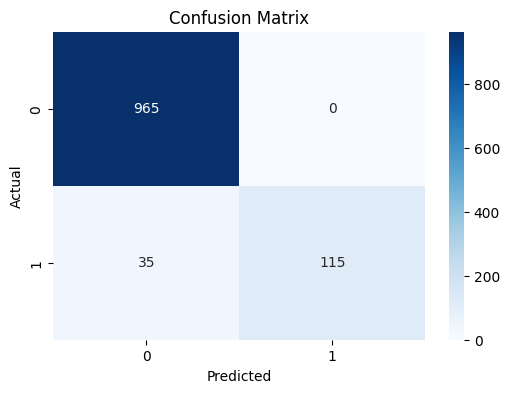

In [18]:
#Confusion Matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
#Test Custom message
sample_message = [
    "Congratulations! You have won a free iPhone. Claim now."
]

sample_vector = vectorizer.transform(sample_message)

prediction = spam_model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message


In [20]:
#save model
import joblib

joblib.dump(spam_model, "spam_detection_model.pkl")

print("Model saved successfully.")

Model saved successfully.
